# Example 04 - Live market demo on the latest ~180 days

End to end on today's data: download roughly the last six months of daily bars for
six large US stocks from Yahoo Finance, build a QUBO that picks three of them, solve
it with QAOA, cross-check against brute force, and report the selected portfolio's
metrics over the same window.

**What "live" means here:** the latest *daily* bars Yahoo Finance has published
(today's bar may be partial while markets are open). There is no intraday streaming.

**Caveat on the metrics:** they are computed on the same window the optimizer saw
(in-sample). They describe the past six months; they are not a forecast and not
out-of-sample performance. The benchmark harness (`run_market_study`) does a proper
train/test split - see [`docs/benchmarks.md`](../docs/benchmarks.md).

**Network:** required. The outputs below reflect the day this notebook was last
executed.

This notebook mirrors `04_live_market_demo.py`, which is the tested source of truth.

In [1]:
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd

import qaoa_portfolio_core as core
from qaoa_portfolio import (
    FinancialMetrics,
    MarketDataLoader,
    QAOAConfig,
    plot_correlation_heatmap,
    plot_risk_return_scatter,
    plot_top_solutions,
    solve_qubo_qaoa,
)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Six large caps from different sectors (tech, semis, banks, staples, energy).
SYMBOLS = ["AAPL", "MSFT", "NVDA", "JPM", "KO", "XOM"]
DAYS_BACK = 180
RISK_FACTOR = 0.5
TARGET_ASSETS = 3
SEED = 2026

In [2]:
from IPython.display import Image, display

def save_and_show(figures, prefix):
    """Save each figure to output/ (like the script) and display the PNG."""
    paths = []
    for name, figure in figures.items():
        path = OUTPUT_DIR / f"{prefix}_{name}.png"
        figure.savefig(path, bbox_inches="tight", dpi=100)
        paths.append(path)
        display(Image(filename=str(path)))
    return paths

## 1. Today's data

180 calendar days is about 125 trading days, comfortably above the 60 the loader's
validation requires. `load_portfolio_data` is a coroutine, so we `await` it.

In [3]:
end = datetime.now()
start = end - timedelta(days=DAYS_BACK)
price_data = await MarketDataLoader().load_portfolio_data(SYMBOLS, start, end)

loaded = list(price_data.columns.get_level_values(0).unique())
closes = pd.DataFrame({s: price_data[(s, "close")] for s in loaded}).dropna()
labels = list(closes.columns)
target_assets = min(TARGET_ASSETS, len(labels))
print(
    f"{len(labels)} assets, {len(closes)} daily bars, "
    f"{closes.index[0].date()} -> {closes.index[-1].date()} (latest bar)"
)

6 assets, 125 daily bars, 2026-04-13 -> 2026-10-08 (latest bar)


## 2. QUBO + solvers

Brute force (2^6 = 64 candidates) cross-checks QAOA. At 6 assets QAOA keeps every
bitstring for decoding, so its answer equals the optimum by construction; P(optimum)
is what measures the circuit (see example 01).

In [4]:
prices = closes.to_numpy(dtype=np.float64)
qubo = core.build_qubo(prices, labels, RISK_FACTOR, target_assets)
exact = core.solve_brute_force(qubo)
optimum_bitstring = "".join("1" if bit else "0" for bit in exact.solution)
result = solve_qubo_qaoa(
    qubo,
    labels=labels,
    config=QAOAConfig(
        layers=1,
        optimizer="cobyla",
        max_iterations=60,
        num_restarts=2,
        seed=SEED,
        target_assets=target_assets,
    ),
    reference_bitstrings=[optimum_bitstring],
)
p_opt = result.metadata["reference_probabilities"][optimum_bitstring]
print(f"QAOA selection:        {', '.join(result.selected_assets)}")
print(f"Brute-force optimum:   {', '.join(exact.selected_assets)}")
print(
    f"QAOA P(optimum) {p_opt:.3f} (uniform {1 / 2 ** len(labels):.3f}), "
    f"P(feasible) {result.metadata['feasible_probability']:.3f}"
)

QAOA selection:        AAPL, MSFT, KO
Brute-force optimum:   AAPL, MSFT, KO
QAOA P(optimum) 0.035 (uniform 0.016), P(feasible) 0.657


## 3. In-sample metrics

Equal-weighted selection over the same window the optimizer saw. **In-sample:** these
numbers describe the past six months, not future or out-of-sample performance.

In [5]:
returns = closes.pct_change().dropna()
selected = list(result.selected_assets)
daily = returns[selected].mean(axis=1)
metrics = {
    "annualized_return": float(FinancialMetrics.annualized_return(daily)),
    "annualized_volatility": float(FinancialMetrics.annualized_volatility(daily)),
    "sharpe_ratio": float(FinancialMetrics.sharpe_ratio(daily)),
    "max_drawdown": float(FinancialMetrics.max_drawdown(daily)),
}
print("Equal-weighted selection over the same window (IN-SAMPLE):")
print(f"  annualized return     {metrics['annualized_return']:+.1%}")
print(f"  annualized volatility {metrics['annualized_volatility']:.1%}")
print(f"  Sharpe ratio (rf 2%)  {metrics['sharpe_ratio']:.2f}")
print(f"  max drawdown          {metrics['max_drawdown']:.1%}")

Equal-weighted selection over the same window (IN-SAMPLE):
  annualized return     +71.8%
  annualized volatility 18.1%
  Sharpe ratio (rf 2%)  3.86
  max drawdown          -10.6%


## 4. Figures

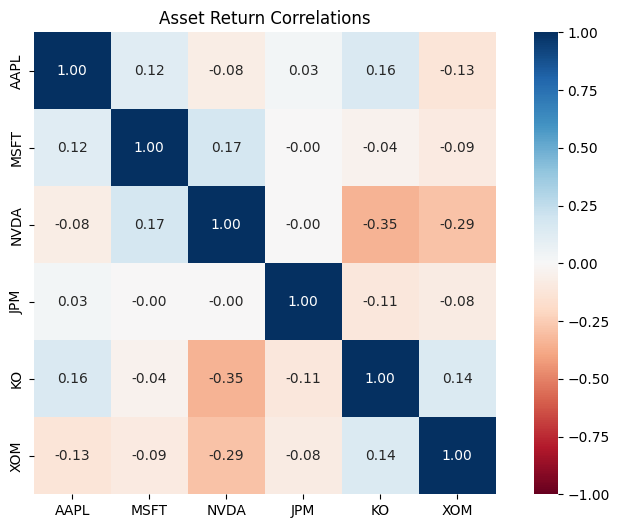

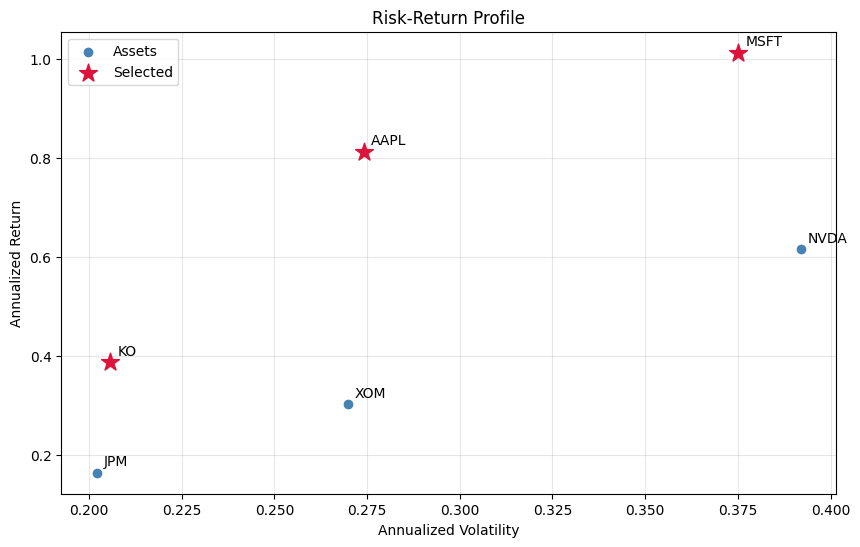

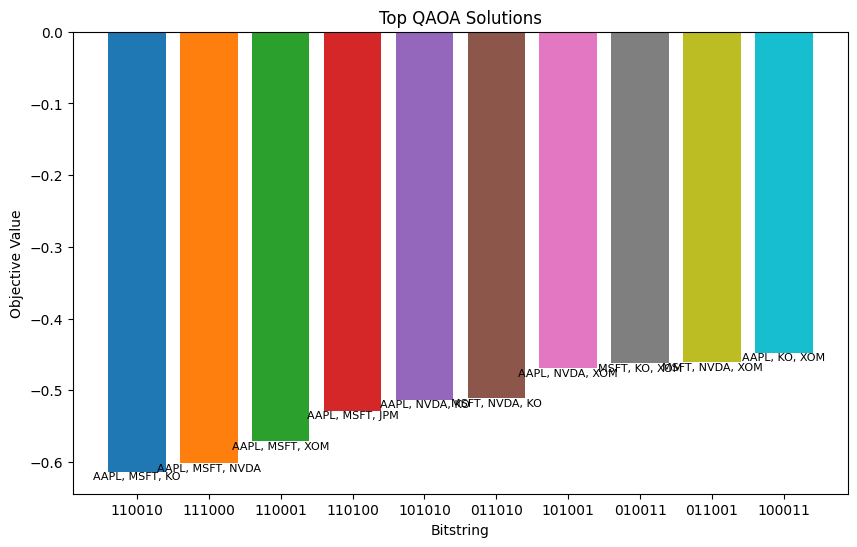

In [6]:
paths = save_and_show(
    {
        "correlation": plot_correlation_heatmap(returns),
        "risk_return": plot_risk_return_scatter(returns, highlighted_assets=selected),
        "top_solutions": plot_top_solutions(result),
    },
    prefix="04",
)